# Stimulus omission responses at different flash rates

This notebook generates the plots for Supplementary Figure 8 & 9 & 10, which showcases the omission stimulus responses of the model at different flash rates.

In [1]:
#This file is modified by Nicol

#import packages
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from retina import analysis, train

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

In [2]:
#set path and run osr

#set path
root = os.path.expanduser("~/Documents/LukeCodeOrig/RetinalModel-main")

#run omission stimulus response
osr_query_set = analysis.OSRQuerySet(root, ablate_recurrence=False)
osr_query_set_ablated = analysis.OSRQuerySet(root, ablate_recurrence=True)
#note smoothing in firing_rate and smooth_input_current is important

In [3]:
#plot osr

def plot_osr(ors_query, intesity_ax, max_r, idx, d, firing_ax, plot_latency=False, input_current=False):
    # Intensity plot
    #get last flash onset
    flash_train = ors_query.flash_clip
    indexes_of_negatives = np.where(np.diff(flash_train) < 0)[0]
    last_flash_onset = indexes_of_negatives[-1] + 1#+1
    
    intesity_ax.plot(ors_query.flash_clip, c="black", linewidth=2)
    intesity_ax.spines["top"].set_visible(False)
    intesity_ax.spines["right"].set_visible(False)
    intesity_ax.spines["bottom"].set_visible(False)
    intesity_ax.spines["left"].set_linewidth(2)
    
    fs = 20
    intesity_ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    intesity_ax.set_yticks([0, 1])
    intesity_ax.set_xlim([0, len(ors_query.flash_clip)])
    intesity_ax.set_xticks([])
    intesity_ax.set_xticklabels([])
    intesity_ax.set_xlabel("")
    #intesity_ax.set_ylabel("Intensity", fontsize=fs, labelpad=35, rotation=0)
    
    # Firing rate plot
    firing_ax.plot([last_flash_onset, last_flash_onset], [0, 1], "--", c="black", linewidth=2)
    firing_ax.plot([388-d, 388-d], [0, 1], "--", c="black", linewidth=2)
    if (idx in ors_query.OSR_idx):
        color = 'red'
    else:
        color = 'blue'
    if input_current:
        #print("plotting input current")
        input_current = ors_query.smooth_input_current[idx]
        #print(input_current.min())
        #print(input_current.max())
        firing_ax.plot(input_current, linewidth=3, c=color) # 58
    else:
        firing_rate = ors_query.firing_rate[idx]
        firing_ax.plot(firing_rate, linewidth=3, c=color) # 58
        #latency, last_peak, penult_peak = ors_query._get_latencies(firing_rate)
        #firing_ax.plot([penult_peak, last_peak]/4.33,[0, 0],linwidth=10,c=color)
    firing_ax.set_xticks([0, 36, 36+120, 36+2*120, 36+3*120])
    firing_ax.set_xticklabels(["", "0", "0.5", "1.0", "1.5"]) 
    
    firing_ax.spines["top"].set_visible(False)
    firing_ax.spines["right"].set_visible(False)
    firing_ax.spines["bottom"].set_linewidth(2)
    firing_ax.spines["left"].set_linewidth(2)
    firing_ax.set_xlim([0, len(ors_query.flash_clip)])
    #firing_ax.set_ylim([0, max_r])
    firing_ax.xaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    firing_ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    
    #firing_ax.set_yticks([0, max_r])
    #firing_ax.set_yticklabels(["0", f"{int(max_r * (240))}"])
    firing_ax.set_xlabel("Time (s)", fontsize=fs, labelpad=8)
    #firing_ax.set_ylabel("Firing rate (Hz)", fontsize=fs, labelpad=10)
    
    return last_flash_onset*4.333

## 16Hz OSR

In [4]:
ors_query_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16)

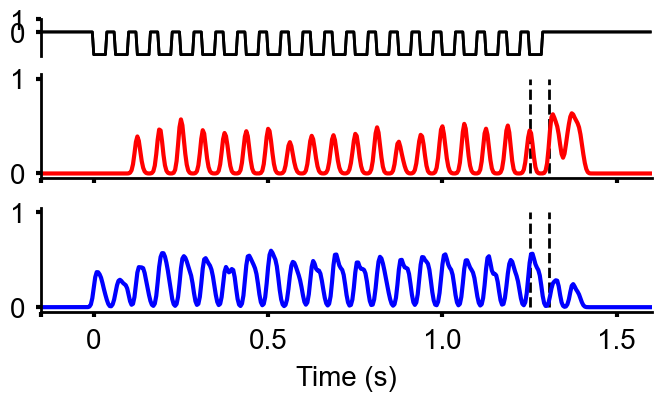

In [32]:
#Plot 16Hz OSR
#Colours need adjusting

fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-15+9+1
plot_osr(ors_query_16hz, intesity_ax, 0.3, 21, d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_16hz, intesity_ax, 1, 393, d, firing2_ax)
plt.savefig(f"{root}/figures/supp/16hz.svg", format="svg", transparent=False, bbox_inches="tight")

## 8Hz OSR

In [6]:
ors_query_8hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=8)

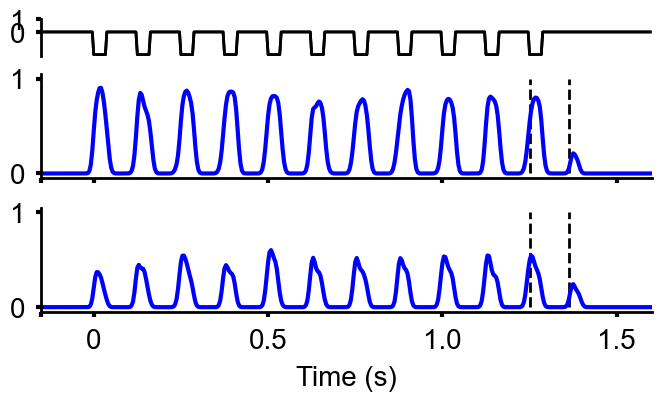

In [34]:
#Plot 16Hz OSR
#Colours need adjusting

fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-30+9+1+1
plot_osr(ors_query_8hz, intesity_ax, 1, 253, d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_8hz, intesity_ax, 0.5, 393, d, firing2_ax)
plt.savefig(f"{root}/figures/supp/8hz.svg", format="svg", transparent=False, bbox_inches="tight")

## 16 Hz with middle of the sequence omission

In [8]:
ors_query_mid_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16, middle_omission=True)

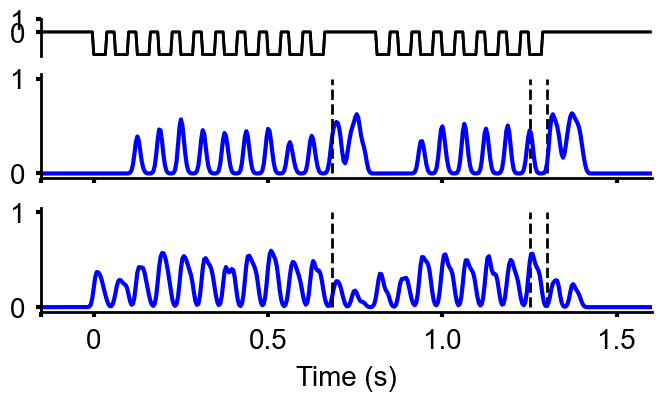

In [35]:
#Plot 16Hz OSR with middle of the sequence omission
#Colours need adjusting


fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

d=44-15+9+1+1
x=200
plot_osr(ors_query_mid_16hz, intesity_ax, 0.3, 21, d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
plot_osr(ors_query_mid_16hz, intesity_ax, 1, 393, d, firing2_ax)
firing1_ax.plot([x, x], [0, 1], "--", c="black", linewidth=2)
firing2_ax.plot([x, x], [0, 1], "--", c="black", linewidth=2)
plt.savefig(f"{root}/figures/supp/mid_16hz.svg", format="svg", transparent=False, bbox_inches="tight")

## Response latency to period relationship

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
    i  period  latency
0   0     125  142.989
1   1     125  138.656
2   2     125  151.655
3   3     125  134.323
4   4     125   43.330
5   5     125  138.656
6   6     125  168.987
7   0      83   60.662
8   1      83   60.662
9   2      83   64.995
10  3      83   69.328
11  4      83   47.663
12  5      83   73.661
13  6      83   69.328
14  0      62  121.324
15  1      62   47.663
16  2      62   60.662
17  3      62   60.662
18  4      62   47.663
19  5      62   56.329
20  6      62   60.662
21  0      50  125.657
22  1      50   43.330
23  2      50   56

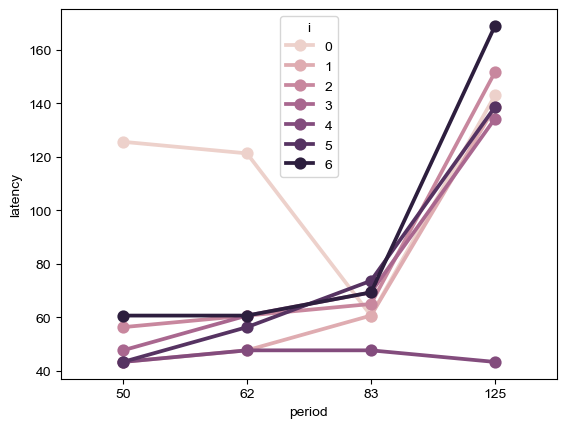

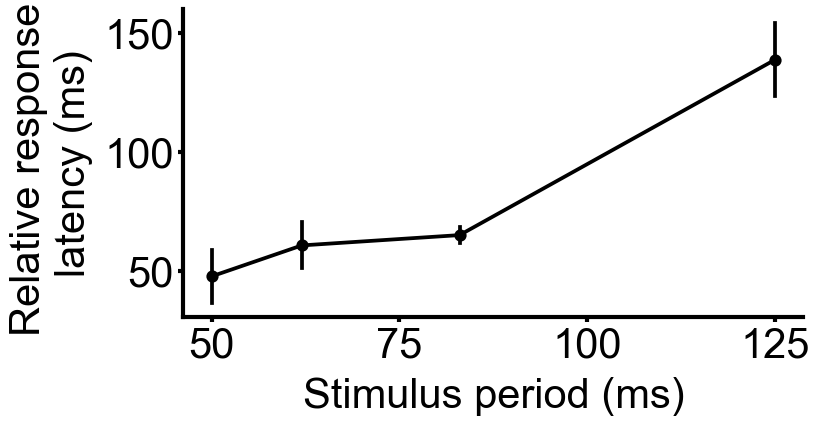

In [10]:
#This is old code and probably can be deleted

def plot_latency_vs_period(df, c, ax):
    #sns.pointplot(df, x="period", y="latency", hue="i")
    sns.pointplot(df, x="period", y="latency", errorbar="se", estimator="median", c=c, ax=ax, native_scale=True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)
    ax.xaxis.set_tick_params(width=3)
    ax.yaxis.set_tick_params(width=3)
    fs = 30
    ax.tick_params(axis="both", which="major", labelsize=fs)
    ax.set_xlabel("Stimulus period (ms)", fontsize=30, labelpad=8)
    ax.set_ylabel("Relative response \nlatency (ms)", fontsize=30, labelpad=8)

sns.pointplot(osr_query_set.get_latency_df(), x="period", y="latency", hue="i")
#sns.lineplot(osr_query_set.get_latency_df().T)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
plot_latency_vs_period(osr_query_set.get_latency_df(), "black", ax)
plt.savefig(f"{root}/figures/supp/rel_resp_lat.svg", format="svg", transparent=False, bbox_inches="tight")
from pprint import pprint
print(osr_query_set.get_latency_df().to_string())

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


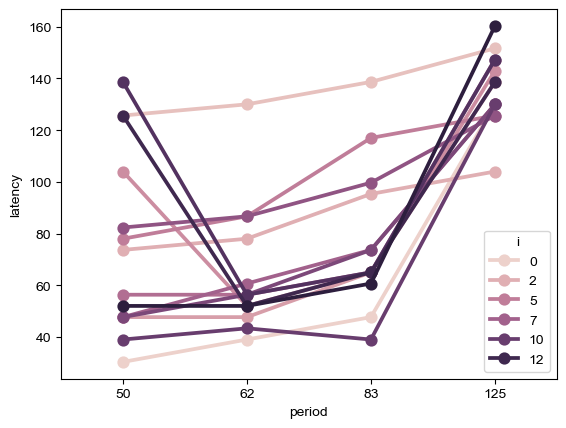

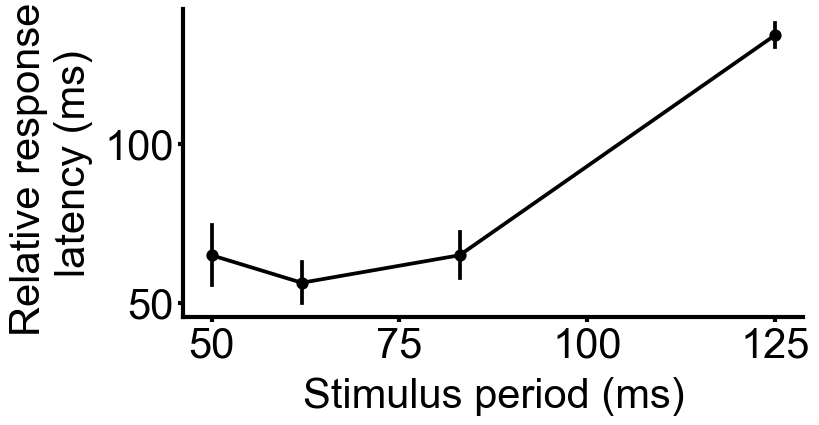

In [11]:
#This is old code and probably can be deleted

def plot_latency_vs_period(df, c, ax):
    sns.pointplot(df, x="period", y="latency", errorbar="se", estimator="median", c=c, ax=ax, native_scale=True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)
    ax.xaxis.set_tick_params(width=3)
    ax.yaxis.set_tick_params(width=3)
    fs = 30
    ax.tick_params(axis="both", which="major", labelsize=fs)
    ax.set_xlabel("Stimulus period (ms)", fontsize=30, labelpad=8)
    ax.set_ylabel("Relative response \nlatency (ms)", fontsize=30, labelpad=8)

sns.pointplot(osr_query_set_ablated.get_latency_df(), x="period", y="latency", hue="i")
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
plot_latency_vs_period(osr_query_set_ablated.get_latency_df(), "black", ax)
plt.savefig(f"{root}/figures/supp/rel_resp_lat_ablated.svg", format="svg", transparent=False, bbox_inches="tight")

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


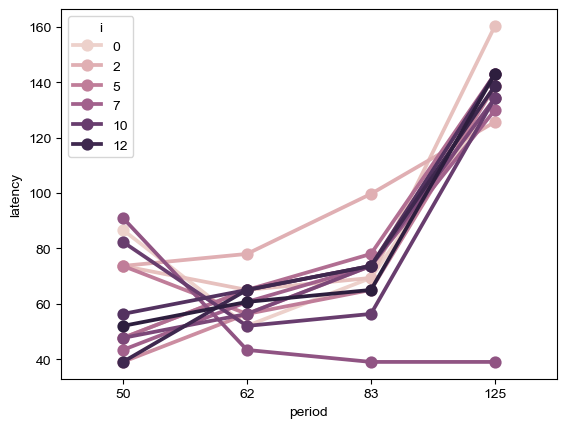

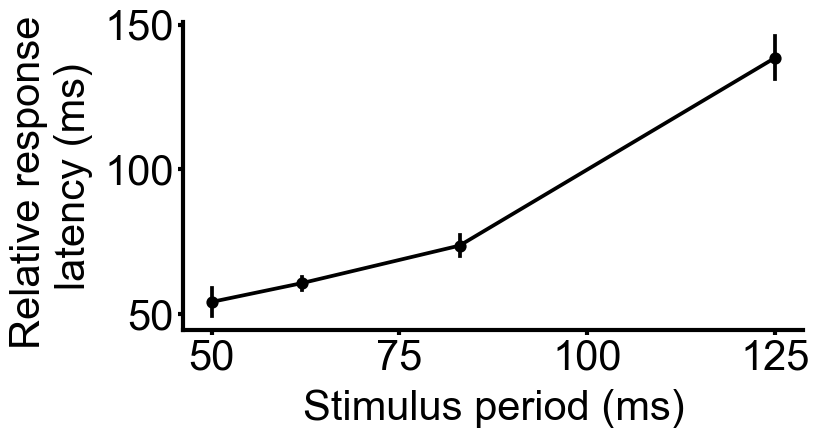

In [12]:
#This is old code and probably can be deleted

def plot_latency_vs_period(df, c, ax):
    sns.pointplot(df, x="period", y="latency", errorbar="se", estimator="median", c=c, ax=ax, native_scale=True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(3)
    ax.spines["bottom"].set_linewidth(3)
    ax.xaxis.set_tick_params(width=3)
    ax.yaxis.set_tick_params(width=3)
    fs = 30
    ax.tick_params(axis="both", which="major", labelsize=fs)
    ax.set_xlabel("Stimulus period (ms)", fontsize=30, labelpad=8)
    ax.set_ylabel("Relative response \nlatency (ms)", fontsize=30, labelpad=8)

sns.pointplot(osr_query_set_ablated.get_input_current_latency_df(), x="period", y="latency", hue="i")
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
plot_latency_vs_period(osr_query_set_ablated.get_input_current_latency_df(), "black", ax)#Nicol
plt.savefig(f"{root}/figures/supp/rel_resp_lat_ablated.svg", format="svg", transparent=False, bbox_inches="tight")

In [24]:
#Not sure, but maybe this can be deleted

##pprint(vars(osr_query_mid_16hz))
osr_query_8hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=8, middle_omission=False)
osr_query_12hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=12, middle_omission=False)
osr_query_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16, middle_omission=False)
osr_query_20hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=20, middle_omission=False)
osr_query_ablate_8hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=8, middle_omission=False, ablate_recurrence=True)
osr_query_ablate_12hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=12, middle_omission=False, ablate_recurrence=True)
osr_query_ablate_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16, middle_omission=False, ablate_recurrence=True)
osr_query_ablate_20hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=20, middle_omission=False, ablate_recurrence=True)
osr_query_mid_16hz = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300, hz=16, middle_omission=True)
#from pprint import pprint
#pprint(vars(osr_query_mid_16hz))

In [25]:
#Not sure, but maybe this can be deleted

osr_query_set._get_peaks_and_latencies

<bound method OSRQuerySet._get_peaks_and_latencies of <retina.analysis.osr.OSRQuerySet object at 0x7fb8540dd820>>

In [1]:
#New code by Nicol
#Plot OSR of every unit for every rate
#get timing of last stimulus response and first OSR
#This is exploratory code and maybe isn't needed for the final code


fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

from pprint import pprint
pprint(osr_query_8hz.OSR_idx)
pprint(osr_query_12hz.OSR_idx)
pprint(osr_query_16hz.OSR_idx)
pprint(osr_query_20hz.OSR_idx)
#pprint(vars(ors_query_mid_16hz))
pprint(osr_query_mid_16hz._spikes.shape)

d=44-15+9+1+1
x=200
plot_osr(osr_query_mid_16hz, intesity_ax, 0.3, osr_query_mid_16hz.OSR_idx[0], d, firing1_ax)
firing1_ax.set_xlabel(None)
firing1_ax.set_xticklabels([])
#plot_osr(osr_query_mid_16hz, intesity_ax, 1, osr_query_mid_16hz.OSR_idx[1], d, firing2_ax)
#firing1_ax.plot([x, x], [0, 1], "--", c="black", linewidth=2)
#firing2_ax.plot([x, x], [0, 1], "--", c="black", linewidth=2)
plt.savefig(f"{root}/figures/supp/mid_16hz.svg", format="svg", transparent=False, bbox_inches="tight")

#Nicol
fig = plt.figure(constrained_layout=True, figsize=(1.3*5, 1.3*3))
spec = gridspec.GridSpec(nrows=3, ncols=1, height_ratios=[0.35, 1, 1], hspace=0.1, figure=fig)
intesity_ax = fig.add_subplot(spec[0])
firing1_ax = fig.add_subplot(spec[1]) 
firing2_ax = fig.add_subplot(spec[2]) 

lfp_list = np.full((400, 4), np.nan)#first flash peak
lfp_list = np.full((400, 4), np.nan)#last flash peak
osr_list = np.full((400, 4), np.nan)#first omission response
lfp_list_ablate = np.full((400, 4), np.nan)
lfp_list_ablate = np.full((400, 4), np.nan)
osr_list_ablate = np.full((400, 4), np.nan)
ffp_list_input = np.full((400, 4), np.nan)
lfp_list_input = np.full((400, 4), np.nan)
osr_list_input = np.full((400, 4), np.nan)

#latency_list = np.full((400,4), np.nan)

peak_delay = 2
match_firing_version = False
valid_units = 0;
valid_units_ablate = 0;
valid_units_input = 0;
for n in range(400):
    if (n in osr_query_8hz.responsive_idx) or (n in osr_query_12hz.responsive_idx) or (n in osr_query_8hz.responsive_idx) and (n in osr_query_8hz.responsive_idx):
        x=200
        #Firing rate
        fig = plt.figure(constrained_layout=True, figsize=(1.3*6, 1.3*2))
        spec = gridspec.GridSpec(nrows=8, ncols=1, height_ratios=[0.2, 1, 0.2, 1, 0.2, 1, 0.2, 1], hspace=0.1, figure=fig)
        intesity1_ax = fig.add_subplot(spec[0])
        plt.title('Unit: n=%i' %n)
        firing1_ax = fig.add_subplot(spec[1]) 
        #pprint("n")
        #pprint(n)
        d=44-15+9+1+4-20
        #if n
        last_flash_onset = plot_osr(osr_query_8hz, intesity1_ax, 1, n, d, firing1_ax)
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_8hz.firing_rate[n])
        final_peaks1 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks1.size > 1:
            #print(peaks)
            #print(final_peaks1)
            last_flash_peak1 = peaks[final_peaks1[0]]/4.33
            first_osr_peak1 = peaks[final_peaks1[1]]/4.33
            #print(final_peaks)
            latencycolor = "red"
            firing1_ax.plot([last_flash_peak1, first_osr_peak1],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak1 = np.nan
            first_osr_peak1 = np.nan
        intesity2_ax = fig.add_subplot(spec[2])
        firing2_ax = fig.add_subplot(spec[3]) 
        d=44-15+9+1+3-10
        last_flash_onset = plot_osr(osr_query_12hz, intesity2_ax, 1, n, d, firing2_ax)
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_12hz.firing_rate[n])
        final_peaks2 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks2.size > 1:
            #print(peaks)
            #print(final_peaks2)
            last_flash_peak2 = peaks[final_peaks2[0]]/4.33
            first_osr_peak2 = peaks[final_peaks2[1]]/4.33
            latencycolor = "red"
            firing2_ax.plot([last_flash_peak2, first_osr_peak2],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak2 = np.nan
            first_osr_peak2 = np.nan
        intesity3_ax = fig.add_subplot(spec[4])
        firing3_ax = fig.add_subplot(spec[5]) 
        d=44-15+9+1+2-4
        last_flash_onset = plot_osr(osr_query_16hz, intesity3_ax, 1, n, d, firing3_ax)
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_16hz.firing_rate[n])
        final_peaks3 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks3.size > 1:
            #print(peaks)
            #print(final_peaks3)
            last_flash_peak3 = peaks[final_peaks3[0]]/4.33
            first_osr_peak3 = peaks[final_peaks3[1]]/4.33
            latencycolor = "red"
            firing3_ax.plot([last_flash_peak3, first_osr_peak3],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak3 = np.nan
            first_osr_peak3 = np.nan
        intesity4_ax = fig.add_subplot(spec[6])
        firing4_ax = fig.add_subplot(spec[7]) 
        d=44-15+9+1+1
        last_flash_onset = plot_osr(osr_query_20hz, intesity4_ax, 1, n, d, firing4_ax)
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_20hz.firing_rate[n])
        final_peaks4 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks4.size > 1:
            #print(peaks)
            #print(final_peaks4)
            last_flash_peak4 = peaks[final_peaks4[0]]/4.33
            first_osr_peak4 = peaks[final_peaks4[1]]/4.33
            latencycolor = "red"
            firing4_ax.plot([last_flash_peak4, first_osr_peak4],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak4 = np.nan
            first_osr_peak4 = np.nan
        if (final_peaks1.size > 1) or (final_peaks2.size > 1) or (final_peaks3.size > 1) or (final_peaks4.size > 1):
            lfp_list[valid_units,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
            osr_list[valid_units,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
            isvalid = True
            valid_units += 1
        else:
            isvalid = False
        #firing1_ax.set_xlabel(None)
        #firing1_ax.set_xticklabels([])
        #firing1_ax.plot([x, x], [0, 1], "--", c="black", linewidth=1)
        #firing2_ax.plot([x, x], [0, 1], "--", c="black", linewidth=1)
        #Plot input currents
        
        #Firing rate, ablated recurrency
        fig = plt.figure(constrained_layout=True, figsize=(1.3*6, 1.3*2))
        spec = gridspec.GridSpec(nrows=8, ncols=1, height_ratios=[0.2, 1, 0.2, 1, 0.2, 1, 0.2, 1], hspace=0.1, figure=fig)
        intesity1_ax = fig.add_subplot(spec[0])
        plt.title('Unit: n=%i' %n)
        firing1_ax = fig.add_subplot(spec[1]) 
        #pprint("n")
        #pprint(n)
        d=44-15+9+1+4-20
        #if n
        last_flash_onset = plot_osr(osr_query_ablate_8hz, intesity1_ax, 1, n, d, firing1_ax)
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_ablate_8hz.firing_rate[n])
        final_peaks1 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks1.size > 1:
            #print(peaks)
            #print(final_peaks1)
            last_flash_peak1 = peaks[final_peaks1[0]]/4.33
            first_osr_peak1 = peaks[final_peaks1[1]]/4.33
            #print(final_peaks)
            latencycolor = "red"
            firing1_ax.plot([last_flash_peak1, first_osr_peak1],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak1 = np.nan
            first_osr_peak1 = np.nan
        intesity2_ax = fig.add_subplot(spec[2])
        firing2_ax = fig.add_subplot(spec[3]) 
        d=44-15+9+1+3-10
        last_flash_onset = plot_osr(osr_query_ablate_12hz, intesity2_ax, 1, n, d, firing2_ax)
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_ablate_12hz.firing_rate[n])
        final_peaks2 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks2.size > 1:
            #print(peaks)
            #print(final_peaks2)
            last_flash_peak2 = peaks[final_peaks2[0]]/4.33
            first_osr_peak2 = peaks[final_peaks2[1]]/4.33
            latencycolor = "red"
            firing2_ax.plot([last_flash_peak2, first_osr_peak2],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak2 = np.nan
            first_osr_peak2 = np.nan
        intesity3_ax = fig.add_subplot(spec[4])
        firing3_ax = fig.add_subplot(spec[5]) 
        d=44-15+9+1+2-4
        last_flash_onset = plot_osr(osr_query_ablate_16hz, intesity3_ax, 1, n, d, firing3_ax)
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_ablate_16hz.firing_rate[n])
        final_peaks3 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks3.size > 1:
            #print(peaks)
            #print(final_peaks3)
            last_flash_peak3 = peaks[final_peaks3[0]]/4.33
            first_osr_peak3 = peaks[final_peaks3[1]]/4.33
            latencycolor = "red"
            firing3_ax.plot([last_flash_peak3, first_osr_peak3],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak3 = np.nan
            first_osr_peak3 = np.nan
        intesity4_ax = fig.add_subplot(spec[6])
        firing4_ax = fig.add_subplot(spec[7]) 
        d=44-15+9+1+1
        last_flash_onset = plot_osr(osr_query_ablate_20hz, intesity4_ax, 1, n, d, firing4_ax)
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_ablate_20hz.firing_rate[n])
        final_peaks4 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks4.size > 1:
            #print(peaks)
            #print(final_peaks4)
            last_flash_peak4 = peaks[final_peaks4[0]]/4.33
            first_osr_peak4 = peaks[final_peaks4[1]]/4.33
            latencycolor = "red"
            firing4_ax.plot([last_flash_peak4, first_osr_peak4],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak4 = np.nan
            first_osr_peak4 = np.nan
        if match_firing_version:
            if isvalid:
                lfp_list_ablate[valid_units,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
                osr_list_ablate[valid_units,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
        else:
            if (final_peaks1.size > 1) or (final_peaks2.size > 1) or (final_peaks3.size > 1) or (final_peaks4.size > 1):
                lfp_list_ablate[valid_units_ablate,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
                osr_list_ablate[valid_units_ablate,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
                valid_units_ablate += 1
            
        #Input current
        fig = plt.figure(constrained_layout=True, figsize=(1.3*6, 1.3*2))
        spec = gridspec.GridSpec(nrows=8, ncols=1, height_ratios=[0.2, 1, 0.2, 1, 0.2, 1, 0.2, 1], hspace=0.1, figure=fig)
        intesity1_ax = fig.add_subplot(spec[0])
        plt.title('Unit: n=%i' %n)
        firing1_ax = fig.add_subplot(spec[1]) 
        #pprint("n")
        #pprint(n)
        d=44-15+9+1+4-20
        #if n
        last_flash_onset = plot_osr(osr_query_8hz, intesity1_ax, 1, n, d, firing1_ax, input_current=True)
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_8hz.smooth_input_current[n])
        final_peaks1 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks1.size > 1:
            #print(peaks)
            #print(final_peaks1)
            last_flash_peak1 = peaks[final_peaks1[0]]/4.33
            first_osr_peak1 = peaks[final_peaks1[1]]/4.33
            #print(final_peaks)
            latencycolor = "red"
            firing1_ax.plot([last_flash_peak1, first_osr_peak1],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak1 = np.nan
            first_osr_peak1 = np.nan
        intesity2_ax = fig.add_subplot(spec[2])
        firing2_ax = fig.add_subplot(spec[3]) 
        d=44-15+9+1+3-10
        last_flash_onset = plot_osr(osr_query_12hz, intesity2_ax, 1, n, d, firing2_ax, input_current=True)
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_12hz.smooth_input_current[n])
        final_peaks2 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks2.size > 1:
            #print(peaks)
            #print(final_peaks2)
            last_flash_peak2 = peaks[final_peaks2[0]]/4.33
            first_osr_peak2 = peaks[final_peaks2[1]]/4.33
            latencycolor = "red"
            firing2_ax.plot([last_flash_peak2, first_osr_peak2],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak2 = np.nan
            first_osr_peak2 = np.nan
        intesity3_ax = fig.add_subplot(spec[4])
        firing3_ax = fig.add_subplot(spec[5]) 
        d=44-15+9+1+2-4
        last_flash_onset = plot_osr(osr_query_16hz, intesity3_ax, 1, n, d, firing3_ax, input_current=True)
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_16hz.smooth_input_current[n])
        final_peaks3 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks3.size > 1:
            #print(peaks)
            #print(final_peaks3)
            last_flash_peak3 = peaks[final_peaks3[0]]/4.33
            first_osr_peak3 = peaks[final_peaks3[1]]/4.33
            latencycolor = "red"
            firing3_ax.plot([last_flash_peak3, first_osr_peak3],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak3 = np.nan
            first_osr_peak3 = np.nan
        intesity4_ax = fig.add_subplot(spec[6])
        firing4_ax = fig.add_subplot(spec[7]) 
        d=44-15+9+1+1
        last_flash_onset = plot_osr(osr_query_20hz, intesity4_ax, 1, n, d, firing4_ax, input_current=True)
        latency, last_peak, penult_peak, peaks = osr_query_set._get_peaks_and_latencies(osr_query_20hz.smooth_input_current[n])
        final_peaks4 = np.where(peaks > last_flash_onset+peak_delay)[0]
        if final_peaks4.size > 1:
            #print(peaks)
            #print(final_peaks4)
            last_flash_peak4 = peaks[final_peaks4[0]]/4.33
            first_osr_peak4 = peaks[final_peaks4[1]]/4.33
            latencycolor = "red"
            firing4_ax.plot([last_flash_peak4, first_osr_peak4],[0,0],linewidth=3,c=latencycolor)
        else:
            last_flash_peak4 = np.nan
            first_osr_peak4 = np.nan
        if match_firing_version:
            if isvalid:
                lfp_list_input[valid_units,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
                osr_list_input[valid_units,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
        else:
            if (final_peaks1.size > 1) or (final_peaks2.size > 1) or (final_peaks3.size > 1) or (final_peaks4.size > 1):
                lfp_list_input[valid_units_input,:] = [last_flash_peak1, last_flash_peak2, last_flash_peak3, last_flash_peak4]
                osr_list_input[valid_units_input,:] = [first_osr_peak1, first_osr_peak2, first_osr_peak3, first_osr_peak4]
                valid_units_input += 1
        
#         fig = plt.figure(constrained_layout=True, figsize=(1.3*6, 1.3*2))
#         spec = gridspec.GridSpec(nrows=8, ncols=1, height_ratios=[0.2, 1, 0.2, 1, 0.2, 1, 0.2, 1], hspace=0.1, figure=fig)
#         intesity1_ax = fig.add_subplot(spec[0])
#         plt.title('Unit: n=%i' %n)
#         firing1_ax = fig.add_subplot(spec[1]) 
#         #pprint("n")
#         #pprint(n)
#         d=44-15+9+1+4-20
#         #if n
#         plot_osr(osr_query_8hz, intesity1_ax, 1, n, d, firing1_ax, input_current=True)
#         intesity2_ax = fig.add_subplot(spec[2])
#         firing2_ax = fig.add_subplot(spec[3]) 
#         d=44-15+9+1+3-10
#         plot_osr(osr_query_12hz, intesity2_ax, 1, n, d, firing2_ax, input_current=True)
#         intesity3_ax = fig.add_subplot(spec[4])
#         firing3_ax = fig.add_subplot(spec[5]) 
#         d=44-15+9+1+2-4
#         plot_osr(osr_query_16hz, intesity3_ax, 1, n, d, firing3_ax, input_current=True)
#         intesity4_ax = fig.add_subplot(spec[6])
#         firing4_ax = fig.add_subplot(spec[7]) 
#         d=44-15+9+1+1
#         plot_osr(osr_query_20hz, intesity4_ax, 1, n, d, firing4_ax, input_current=True)

# pprint(valid_units)
# lfp_list = lfp_list[:valid_units,:]
# pprint(lfp_list)
# osr_list = osr_list[:valid_units,:]
# pprint(osr_list)
# lfp_list = lfp_list[:valid_units,:]
# pprint(lfp_list_ablate)
# osr_list = osr_list[:valid_units,:]
# pprint(osr_list_ablate)
# lfp_list = lfp_list[:valid_units,:]
# pprint(lfp_list_input)
# osr_list = osr_list[:valid_units,:]
# pprint(osr_list_input)


NameError: name 'plt' is not defined

In [2]:
#New code by Nicol
#plot mean population OSR latency relative last flash responase peak against stimulus period,
#for standard model, model with ablated recurrency, and feedforward input
#plot OSR latency for each unit for these three conditions (3 plots)
#plot mean population OSR latency relative to last flash onset against stimulus period,
#for standard model, model with ablated recurrency, and feedforward input

import matplotlib.pyplot as plt

# Global plot style settings
plt.rcParams.update({
    'font.size': 24,          # 2x default font size (12 → 24)
    'lines.linewidth': 2.5,   # 2x default line width (~1.25 → 2.5)
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2.0     # make bottom/left axes thicker
})

last_flash_onset1 = plot_osr(osr_query_8hz, intesity1_ax, 1, n, d, firing1_ax)
last_flash_onset2 = plot_osr(osr_query_12hz, intesity1_ax, 1, n, d, firing1_ax)
last_flash_onset3 = plot_osr(osr_query_16hz, intesity1_ax, 1, n, d, firing1_ax)
last_flash_onset4 = plot_osr(osr_query_20hz, intesity1_ax, 1, n, d, firing1_ax)
lfo = [last_flash_onset4, last_flash_onset3, last_flash_onset2, last_flash_onset1]
print(lfo)
print(last_flash_onset2/4.333)

pprint(valid_units)
lfp_list = lfp_list[:valid_units,:]
pprint(lfp_list)
osr_list = osr_list[:valid_units,:]
pprint(osr_list)
if match_firing_version:
    lfp_list_ablate = lfp_list_ablate[:valid_units,:]
    pprint(lfp_list_ablate)
    osr_list_ablate = osr_list_ablate[:valid_units,:]
    pprint(osr_list_ablate)
    lfp_list_input = lfp_list_input[:valid_units,:]
    pprint(lfp_list_input)
    osr_list_input = osr_list_input[:valid_units,:]
    pprint(osr_list_input)
else:
    lfp_list_ablate = lfp_list_ablate[:valid_units_ablate,:]
    pprint(lfp_list_ablate)
    osr_list_ablate = osr_list_ablate[:valid_units_ablate,:]
    pprint(osr_list_ablate)
    lfp_list_input = lfp_list_input[:valid_units_input,:]
    pprint(lfp_list_input)
    osr_list_input = osr_list_input[:valid_units_input,:]
    pprint(osr_list_input)


latencies = np.fliplr(osr_list - lfp_list)*4.333
meanlatency = np.nanmean(latencies,axis=0)
semlatency = np.nanstd(latencies,axis=0)/np.sum(~np.isnan(latencies),axis=0)
pprint(meanlatency)
periods = np.array([50, 62.5, 83.3, 125])
plt.errorbar(periods,meanlatency,semlatency)

latencies_ablate = np.fliplr(osr_list_ablate - lfp_list_ablate)*4.333
meanlatency_ablate = np.nanmean(latencies_ablate,axis=0)
semlatency_ablate = np.nanstd(latencies_ablate,axis=0)/np.sum(~np.isnan(latencies_ablate),axis=0)
pprint(meanlatency_ablate)
plt.errorbar(periods,meanlatency_ablate,semlatency_ablate)

latencies_input = np.fliplr(osr_list_input - lfp_list_input)*4.333
meanlatency_input = np.nanmean(latencies_input,axis=0)
semlatency_input = np.nanstd(latencies_input,axis=0)/np.sum(~np.isnan(latencies_input),axis=0)
pprint(meanlatency_input)
plt.errorbar(periods,meanlatency_input,semlatency_input)

plt.figure()
plt.plot(periods,latencies.T)
print(latencies.shape)

plt.figure()
plt.plot(periods,latencies_ablate.T)
print(latencies_ablate.shape)

plt.figure()
plt.plot(periods,latencies_input.T)
print(latencies_input.shape)

plt.figure()
latencies = np.fliplr(osr_list - last_flash_onset1/4.333)*4.333
meanlatency = np.nanmean(latencies,axis=0)
semlatency = np.nanstd(latencies,axis=0)/np.sum(~np.isnan(latencies),axis=0)
pprint(meanlatency)
periods = np.array([50, 62.5, 83.3, 125])
plt.errorbar(periods,meanlatency,semlatency)

latencies_ablate = np.fliplr(osr_list_ablate - last_flash_onset1/4.333)*4.333
meanlatency_ablate = np.nanmean(latencies_ablate,axis=0)
semlatency_ablate = np.nanstd(latencies_ablate,axis=0)/np.sum(~np.isnan(latencies_ablate),axis=0)
pprint(meanlatency_ablate)
plt.errorbar(periods,meanlatency_ablate,semlatency_ablate)

latencies_input = np.fliplr(osr_list_input  - last_flash_onset1/4.333)*4.333
meanlatency_input = np.nanmean(latencies_input,axis=0)
semlatency_input = np.nanstd(latencies_input,axis=0)/np.sum(~np.isnan(latencies_input),axis=0)
pprint(meanlatency_input)
plt.errorbar(periods,meanlatency_input,semlatency_input)

NameError: name 'plot_osr' is not defined

## Inspection of spatiotemporal RFs of OSR units

In [182]:
ors_query = analysis.OSRQuery(root, start_ms=150, duration_ms=1300, end_ms=300)

In [183]:
enc_model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_0_8")
pred_model = train.Trainer.load_model(f"{root}/results", "0.0031622776601683794_*_0.01_0.6_128_8")
enc_rf_query = analysis.RFQuery(root, enc_model)
pred_rf_query = analysis.RFQuery(root, pred_model)

INFO:util:Processing batch 0 out of 4...
INFO:util:Processing batch 1 out of 4...
INFO:util:Processing batch 2 out of 4...
INFO:util:Processing batch 3 out of 4...
INFO:gaussian:Fitting gaussians for batch 0...
INFO:gaussian:Fitting gaussians for batch 1...


KeyboardInterrupt: 

In [ ]:
def plot_spatiotemporal_rf(strf, i, subspec, fig):
    strf = strf.cpu().detach()
    maxv = strf.abs().max()
    
    for j in range(3, len(strf)):
        ax = plt.Subplot(fig, subspec[i, j])
        fig.add_subplot(ax)
        im = ax.imshow(strf[j], cmap="bwr", vmin=-maxv, vmax=maxv)
        ax.axis("off")

In [ ]:
l = 30
fig = plt.figure(constrained_layout=True, figsize=(30, 14))
spec = gridspec.GridSpec(nrows=2, ncols=1, height_ratios=[1, 1], hspace=0.2)
top_spec = gridspec.GridSpecFromSubplotSpec(8, 50, subplot_spec=spec[0], hspace=0.1)
bottom_spec = gridspec.GridSpecFromSubplotSpec(8, 50, subplot_spec=spec[1], hspace=0.1)

plot_spatiotemporal_rf(pred_rf_query.og_strfs[8, :], 0, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[17, :], 1, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[21, :], 2, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[29, :], 3, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[47, :], 4, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[79, :], 5, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[89, :], 6, top_spec, fig)
plot_spatiotemporal_rf(pred_rf_query.og_strfs[178, :], 7, top_spec, fig)

plot_spatiotemporal_rf(enc_rf_query.og_strfs[2, :], 0, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[5, :], 1, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[35, :], 2, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[56, :], 3, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[70, :], 4, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[89, :], 5, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[127, :], 6, bottom_spec, fig)
plot_spatiotemporal_rf(enc_rf_query.og_strfs[359, :], 7, bottom_spec, fig)